In [1]:
# 1. 설치
!pip install transformers datasets scikit-learn accelerate konlpy kss -q
!pip install python-mecab-ko -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 63.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 23.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# 2. 기본 셋업 + 데이터 로드
import torch, json, os, numpy as np, pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import roc_auc_score
import kss

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'디바이스: {device}')

if not os.path.exists('katfishnet'):
    os.system('git clone https://github.com/Shinwoo-Park/detecting_llm_generated_korean_text_through_linguistic_analysis.git katfishnet')

def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

essay    = load_jsonl('katfishnet/katfish_dataset/essay.jsonl')
abstract = load_jsonl('katfishnet/katfish_dataset/abstract.jsonl')
poetry   = load_jsonl('katfishnet/katfish_dataset/poetry.jsonl')

df_essay    = pd.DataFrame(essay);    df_essay['genre']    = 'essay'
df_abstract = pd.DataFrame(abstract); df_abstract['genre'] = 'abstract'
df_poetry   = pd.DataFrame(poetry);   df_poetry['genre']   = 'poetry'
df_all = pd.concat([df_essay, df_abstract, df_poetry]).reset_index(drop=True)

human_df   = df_all[df_all['label'] == 0]
human_test = human_df.sample(frac=0.2, random_state=42)
llm_groups = {
    'Solar':    df_all[df_all['written_by'].str.contains('solar',  case=False, na=False)],
    'Qwen2':    df_all[df_all['written_by'].str.contains('qwen',   case=False, na=False)],
    'Llama3.1': df_all[df_all['written_by'].str.contains('llama',  case=False, na=False)],
}
print("데이터 준비 완료")

디바이스: cuda
데이터 준비 완료


In [3]:
# 3. 함수 정의
def compute_binoculars_original(text, m_obs, tok_obs, m_per, tok_per, device, max_length=256):
    inp_o = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        loss_o = m_obs(**inp_o, labels=inp_o['input_ids']).loss.item()
    inp_p  = tok_per(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_o2 = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        logits_p = m_per(**inp_p).logits
        logits_o = m_obs(**inp_o2).logits
    seq_len = min(logits_p.shape[1], logits_o.shape[1]) - 1
    if seq_len <= 0: return 0.0
    lp = logits_p[:, :seq_len, :]
    lo = logits_o[:, :seq_len, :]
    v  = min(lp.shape[-1], lo.shape[-1])
    lp, lo = lp[..., :v], lo[..., :v]
    cross_loss = -(torch.softmax(lp, dim=-1) * torch.log_softmax(lo, dim=-1)).sum(-1).mean().item()
    return loss_o / (cross_loss + 1e-10)

def compute_sentence_variance(text, m_obs, tok_obs, m_per, tok_per, device):
    try:
        sentences = kss.split_sentences(text)
    except:
        sentences = [s.strip() for s in text.split('.') if len(s.strip()) > 10]
    if len(sentences) < 2:
        return 0.0, 0.0
    scores = []
    for sent in sentences:
        if len(sent.strip()) < 5:
            continue
        try:
            s = compute_binoculars_original(sent, m_obs, tok_obs, m_per, tok_per, device)
            scores.append(s)
        except:
            continue
    if len(scores) < 2:
        return 0.0, 0.0
    return np.mean(scores), np.std(scores)

print("함수 정의 완료")

함수 정의 완료


In [4]:
# 4. Qwen 로드
tok_q1 = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")
m_q1   = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B", torch_dtype=torch.float16, device_map="auto")
m_q1.eval()
tok_q2 = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
m_q2   = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B-Instruct", torch_dtype=torch.float16, device_map="auto")
m_q2.eval()
print("Qwen 로드 완료")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen 로드 완료


In [6]:
def compute_features(text, m_obs, tok_obs, m_per, tok_per, device, max_length=256):
    inp_o = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_p = tok_per(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_o2 = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        loss_o = m_obs(**inp_o, labels=inp_o['input_ids']).loss.item()
        logits_o = m_obs(**inp_o2).logits
        logits_p = m_per(**inp_p).logits
    seq_len = min(logits_o.shape[1], logits_p.shape[1]) - 1
    if seq_len <= 0:
        return {'bino': 0.0, 'nll_std': 0.0}
    lo = logits_o[:, :seq_len, :]
    lp = logits_p[:, :seq_len, :]
    v = min(lo.shape[-1], lp.shape[-1])
    lo, lp = lo[..., :v], lp[..., :v]

    ce = -(torch.softmax(lp[0], dim=-1) * torch.log_softmax(lo[0], dim=-1)).sum(-1)
    bino = loss_o / (ce.mean().item() + 1e-10)

    ids = inp_o['input_ids'][0, 1:seq_len+1]
    log_probs = torch.log_softmax(lo[0], dim=-1)
    nll = -log_probs[torch.arange(seq_len, device=device), ids]
    nll_std = nll.cpu().float().numpy().std()

    return {'bino': bino, 'nll_std': nll_std}

print("함수 정의 완료")

함수 정의 완료


In [7]:
# 이미 로드된 Qwen2.5-3B로 텍스트 생성
# 같은 프롬프트 × temperature 4가지

prompts = [
    "한국의 전통 음식에 대해 설명해주세요.",
    "인공지능의 미래에 대한 에세이를 써주세요.",
    "환경 보호의 중요성에 대해 논해주세요.",
    "교육의 역할에 대한 의견을 말해주세요.",
    "기술 발전이 사회에 미치는 영향을 논하세요.",
]

temperatures = [0.3, 0.7, 1.0, 1.3]

def generate_text(prompt, temperature, model, tokenizer, device, max_new_tokens=200):
    inp = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)

# 각 (prompt, temperature) 조합에서 5개씩 생성 → 총 5*4*5 = 100개
print(f"{'Temp':<8} {'Avg NLL_std':>12} {'Avg Bino':>12}")
print("-" * 36)

results = {t: {'nll_std': [], 'bino': []} for t in temperatures}

for temp in temperatures:
    for prompt in prompts:
        for _ in range(5):  # 각 조합당 5개
            text = generate_text(prompt, temp, m_q2, tok_q2, device)  # instruct 모델로 생성
            if len(text) < 50:
                continue
            feats = compute_features(text, m_q1, tok_q1, m_q2, tok_q2, device)
            results[temp]['nll_std'].append(feats['nll_std'])
            results[temp]['bino'].append(feats['bino'])

    avg_std = np.mean(results[temp]['nll_std'])
    avg_bino = np.mean(results[temp]['bino'])
    print(f"{temp:<8.1f} {avg_std:>12.4f} {avg_bino:>12.4f}")

# 상관계수
from scipy import stats as sp_stats
temps_expanded = []
stds_expanded = []
for t in temperatures:
    for v in results[t]['nll_std']:
        temps_expanded.append(t)
        stds_expanded.append(v)

r, p = sp_stats.pearsonr(temps_expanded, stds_expanded)
print(f"\nTemperature vs NLL_std: r={r:.4f}, p={p:.4f}")

Temp      Avg NLL_std     Avg Bino
------------------------------------
0.3            1.2987       0.6426
0.7            1.4913       0.7424
1.0            1.6964       0.8677
1.3            1.8888       1.0236

Temperature vs NLL_std: r=0.6349, p=0.0000


In [9]:
# feat_df 재계산 (Human + LLM, GPT-4o 제외)
llm_df_all = df_all[
    (df_all['label'] == 1) &
    (~df_all['written_by'].str.contains('gpt', case=False, na=False))
]

all_feats = []
all_labels = []
all_writers = []

total_h = len(human_test)
for i, (_, row) in enumerate(human_test.iterrows()):
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(0)
    all_writers.append('Human')
    print(f"\rHuman: {i+1}/{total_h}", end="")
print(" ✓")

total_l = len(llm_df_all)
for i, (_, row) in enumerate(llm_df_all.iterrows()):
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(1)
    all_writers.append(row['written_by'])
    print(f"\rLLM: {i+1}/{total_l}", end="")
print(" ✓")

feat_df = pd.DataFrame(all_feats)
feat_df['label'] = all_labels
feat_df['writer'] = all_writers

# Temperature 역추정
slope, intercept = 0.6773, -0.2545

print(f"\n회귀식: temp = {slope:.4f} * nll_std + {intercept:.4f}")
print(f"\n{'Group':<15} {'Avg NLL_std':>12} {'Est. Temp':>12}")
print("-" * 42)

# Human
avg_h = feat_df[feat_df['label']==0]['nll_std'].mean()
print(f"{'Human':<15} {avg_h:>12.4f} {slope*avg_h+intercept:>12.4f}")

# LLM별
for llm_match, llm_disp in [('solar', 'Solar'), ('qwen', 'Qwen2'), ('llama', 'Llama3.1')]:
    mask = (feat_df['label']==1) & (feat_df['writer'].str.contains(llm_match, case=False))
    avg_std = feat_df[mask]['nll_std'].mean()
    est_temp = slope * avg_std + intercept
    print(f"{llm_disp:<15} {avg_std:>12.4f} {est_temp:>12.4f}")

Human: 94/94 ✓
LLM: 1154/1154 ✓

회귀식: temp = 0.6773 * nll_std + -0.2545

Group            Avg NLL_std    Est. Temp
------------------------------------------
Human                 2.4085       1.3768
Solar                 1.9242       1.0487
Qwen2                 2.0050       1.1035
Llama3.1              2.0200       1.1136


In [10]:
# Temperature-NLL_std 관계로 각 LLM의 "유효 temperature" 역추정
from scipy.stats import linregress

# Step 1 결과로 선형 회귀
temps = []
stds = []
for t in [0.3, 0.7, 1.0, 1.3]:
    for v in results[t]['nll_std']:
        temps.append(t)
        stds.append(v)

slope, intercept, r_val, p_val, _ = linregress(stds, temps)  # std → temp 방향
print(f"회귀식: temp = {slope:.4f} * nll_std + {intercept:.4f}")
print(f"r={r_val:.4f}, p={p_val:.6f}")

# 각 LLM의 평균 NLL_std로 temperature 역추정
print(f"\n{'Group':<15} {'Avg NLL_std':>12} {'Est. Temp':>12}")
print("-" * 42)

# feat_df가 아직 있으면 사용, 없으면 다시 계산 필요
# human_test의 평균
# (이전 실험의 feat_df가 세션에 있어야 함)

if 'feat_df' in dir():
    for label, name in [(0, 'Human'), (1, 'AI (avg)')]:
        avg_std = feat_df[feat_df['label']==label]['nll_std'].mean()
        est_temp = slope * avg_std + intercept
        print(f"{name:<15} {avg_std:>12.4f} {est_temp:>12.4f}")

    # LLM별
    for llm_match, llm_disp in [('solar', 'Solar'), ('qwen', 'Qwen2'), ('llama', 'Llama3.1')]:
        mask = (feat_df['label']==1) & (feat_df['writer'].str.contains(llm_match, case=False))
        if mask.sum() > 0:
            avg_std = feat_df[mask]['nll_std'].mean()
            est_temp = slope * avg_std + intercept
            print(f"{llm_disp:<15} {avg_std:>12.4f} {est_temp:>12.4f}")
else:
    print("feat_df가 세션에 없음. 이전 실험 재실행 필요.")

회귀식: temp = 0.6773 * nll_std + -0.2545
r=0.6349, p=0.000000

Group            Avg NLL_std    Est. Temp
------------------------------------------
Human                 2.4085       1.3768
AI (avg)              1.9793       1.0861
Solar                 1.9242       1.0488
Qwen2                 2.0050       1.1035
Llama3.1              2.0200       1.1136


In [11]:
def sliding_window_scores(text, m_obs, tok_obs, m_per, tok_per, device,
                          window_size=100, stride=50):
    """텍스트를 sliding window로 쪼개서 각 구간의 Binoculars + NLL_std 계산"""
    # 전체 토큰화
    full_ids = tok_obs(text, add_special_tokens=False)['input_ids']

    if len(full_ids) < window_size:
        # 짧으면 전체를 하나의 window로
        f = compute_features(text, m_obs, tok_obs, m_per, tok_per, device)
        return [{'start': 0, 'end': len(full_ids), 'bino': f['bino'], 'nll_std': f['nll_std']}]

    windows = []
    for start in range(0, len(full_ids) - window_size + 1, stride):
        end = start + window_size
        window_ids = full_ids[start:end]
        window_text = tok_obs.decode(window_ids, skip_special_tokens=True)
        if len(window_text.strip()) < 20:
            continue
        try:
            f = compute_features(window_text, m_obs, tok_obs, m_per, tok_per, device)
            windows.append({
                'start': start,
                'end': end,
                'bino': f['bino'],
                'nll_std': f['nll_std'],
            })
        except Exception as e:
            continue
    return windows


# 테스트: 하이브리드 문서 생성
def make_hybrid(human_text, ai_text, ai_ratio, tokenizer):
    """Human 문서 앞부분 + AI 문서 뒷부분 (token 단위로 섞기)"""
    h_ids = tokenizer(human_text, add_special_tokens=False)['input_ids']
    a_ids = tokenizer(ai_text, add_special_tokens=False)['input_ids']

    # 목표 길이는 human과 비슷하게
    target_len = len(h_ids)
    split_point = int(target_len * (1 - ai_ratio))

    h_part = h_ids[:split_point]
    a_part = a_ids[:target_len - split_point]

    combined_ids = h_part + a_part
    return tokenizer.decode(combined_ids, skip_special_tokens=True), split_point


# 빠른 확인: essay에서 Human과 Solar 하나씩 뽑아서 50% 하이브리드 만들기
human_essay = df_all[(df_all['label']==0) & (df_all['genre']=='essay')].iloc[0]['text']
ai_essay = df_all[(df_all['written_by'].str.contains('solar', case=False)) &
                   (df_all['genre']=='essay')].iloc[0]['text']

hybrid_text, boundary = make_hybrid(human_essay, ai_essay, ai_ratio=0.5, tokenizer=tok_q1)
print(f"하이브리드 생성: 경계 토큰 위치 = {boundary}")
print(f"전체 길이: {len(tok_q1(hybrid_text, add_special_tokens=False)['input_ids'])} 토큰")

windows = sliding_window_scores(hybrid_text, m_q1, tok_q1, m_q2, tok_q2, device,
                                 window_size=100, stride=50)

print(f"\n총 {len(windows)}개 window")
print(f"{'Window':<15} {'Bino':>8} {'NLL_std':>10} {'Label':>10}")
print("-" * 48)
for w in windows:
    # 이 window가 경계 이전(Human)인지 이후(AI)인지
    mid = (w['start'] + w['end']) / 2
    label = "Human" if mid < boundary else "AI"
    print(f"{w['start']}-{w['end']:<10} {w['bino']:>8.4f} {w['nll_std']:>10.4f} {label:>10}")

하이브리드 생성: 경계 토큰 위치 = 307
전체 길이: 615 토큰

총 11개 window
Window              Bino    NLL_std      Label
------------------------------------------------
0-100          1.0803     2.2368      Human
50-150          1.0128     2.2278      Human
100-200          0.9641     2.1764      Human
150-250          1.0291     2.5154      Human
200-300          1.0873     2.3467      Human
250-350          1.1735     3.0434      Human
300-400          0.9049     2.1671         AI
350-450          0.7532     1.8071         AI
400-500          0.7564     1.7789         AI
450-550          0.8737     2.0586         AI
500-600          0.8591     1.9471         AI


In [12]:
def estimate_ai_ratio(windows, threshold_bino, threshold_std, weight=0.5):
    """각 window가 AI인지 판단하고 AI 비율 반환"""
    if len(windows) == 0:
        return 0.0, []

    ai_flags = []
    for w in windows:
        # Fusion 스코어: Binoculars와 NLL_std 둘 다 낮으면 AI
        bino_ai = w['bino'] < threshold_bino
        std_ai = w['nll_std'] < threshold_std
        # 가중 결합
        ai_score = weight * int(bino_ai) + (1-weight) * int(std_ai)
        ai_flags.append(ai_score >= 0.5)

    ai_ratio = sum(ai_flags) / len(ai_flags)
    return ai_ratio, ai_flags


def detect_boundary(windows, ai_flags):
    """Human→AI 전환점 예측 (가장 많이 바뀌는 지점)"""
    if len(ai_flags) < 2:
        return None
    # 연속된 Human 뒤 첫 AI 등장
    for i in range(len(ai_flags)):
        if ai_flags[i]:
            # 이 window의 시작 위치 반환
            return windows[i]['start']
    return None


# Step 1: Human과 AI 데이터에서 threshold 자동 결정
# 전체 Human 문서들과 AI 문서들의 평균 스코어로 threshold 잡기
print("Threshold 계산 중...")
h_binos, h_stds = [], []
for _, row in human_test.iterrows():
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    h_binos.append(f['bino'])
    h_stds.append(f['nll_std'])

ai_binos, ai_stds = [], []
ai_df = df_all[(df_all['label']==1) & (~df_all['written_by'].str.contains('gpt', case=False, na=False))]
for _, row in ai_df.head(100).iterrows():
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    ai_binos.append(f['bino'])
    ai_stds.append(f['nll_std'])

# 중간값을 threshold로
thresh_bino = (np.mean(h_binos) + np.mean(ai_binos)) / 2
thresh_std = (np.mean(h_stds) + np.mean(ai_stds)) / 2

print(f"Threshold: bino={thresh_bino:.4f}, std={thresh_std:.4f}")
print(f"Human 평균: bino={np.mean(h_binos):.4f}, std={np.mean(h_stds):.4f}")
print(f"AI 평균:    bino={np.mean(ai_binos):.4f}, std={np.mean(ai_stds):.4f}")

Threshold 계산 중...
Threshold: bino=0.9495, std=2.0447
Human 평균: bino=1.0810, std=2.4085
AI 평균:    bino=0.8180, std=1.6809


In [13]:
# Step 2: 여러 하이브리드 문서 생성 + 평가
import random
random.seed(42)

# 같은 장르의 Human과 AI 쌍 20개씩 만들기
genres = ['essay', 'poetry']  # abstract는 제외
test_pairs = []

for genre in genres:
    h_list = df_all[(df_all['label']==0) & (df_all['genre']==genre)]['text'].tolist()
    a_list = df_all[(df_all['label']==1) & (df_all['genre']==genre) &
                     (~df_all['written_by'].str.contains('gpt', case=False, na=False))]['text'].tolist()

    n_pairs = min(10, len(h_list), len(a_list))
    for i in range(n_pairs):
        test_pairs.append((h_list[i], a_list[i], genre))

print(f"총 {len(test_pairs)}개 쌍 테스트")

# Step 3: 각 AI 비율에 대해 성능 측정
ai_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
results = {r: {'errors_bino': [], 'errors_fusion': [],
               'boundary_errors_bino': [], 'boundary_errors_fusion': []} for r in ai_ratios}

for h_text, a_text, genre in test_pairs:
    for true_ratio in ai_ratios:
        hybrid, true_boundary = make_hybrid(h_text, a_text, true_ratio, tok_q1)
        windows = sliding_window_scores(hybrid, m_q1, tok_q1, m_q2, tok_q2, device,
                                         window_size=100, stride=50)
        if len(windows) < 2:
            continue

        # Bino only (weight=1.0)
        pred_bino, flags_bino = estimate_ai_ratio(windows, thresh_bino, thresh_std, weight=1.0)
        # Fusion (weight=0.4)
        pred_fusion, flags_fusion = estimate_ai_ratio(windows, thresh_bino, thresh_std, weight=0.4)

        results[true_ratio]['errors_bino'].append(abs(pred_bino - true_ratio))
        results[true_ratio]['errors_fusion'].append(abs(pred_fusion - true_ratio))

        # 경계 검출 (0%, 100%는 경계 없으니 스킵)
        if 0 < true_ratio < 1:
            b_bino = detect_boundary(windows, flags_bino)
            b_fusion = detect_boundary(windows, flags_fusion)
            if b_bino is not None:
                results[true_ratio]['boundary_errors_bino'].append(abs(b_bino - true_boundary))
            if b_fusion is not None:
                results[true_ratio]['boundary_errors_fusion'].append(abs(b_fusion - true_boundary))

# 결과 출력
print(f"\n=== AI 비율 추정 오차 (작을수록 좋음) ===")
print(f"{'True ratio':<12} {'Bino MAE':>12} {'Fusion MAE':>12} {'Δ':>8}")
print("-" * 48)
for r in ai_ratios:
    e_b = np.mean(results[r]['errors_bino']) if results[r]['errors_bino'] else 0
    e_f = np.mean(results[r]['errors_fusion']) if results[r]['errors_fusion'] else 0
    print(f"{r:<12.2f} {e_b:>12.4f} {e_f:>12.4f} {e_f-e_b:>+8.4f}")

print(f"\n=== 경계 위치 검출 오차 (토큰 단위, 작을수록 좋음) ===")
print(f"{'True ratio':<12} {'Bino':>12} {'Fusion':>12}")
print("-" * 40)
for r in [0.25, 0.5, 0.75]:
    e_b = np.mean(results[r]['boundary_errors_bino']) if results[r]['boundary_errors_bino'] else 0
    e_f = np.mean(results[r]['boundary_errors_fusion']) if results[r]['boundary_errors_fusion'] else 0
    print(f"{r:<12.2f} {e_b:>12.1f} {e_f:>12.1f}")

총 20개 쌍 테스트

=== AI 비율 추정 오차 (작을수록 좋음) ===
True ratio       Bino MAE   Fusion MAE        Δ
------------------------------------------------
0.00               0.0559       0.0242  -0.0317
0.25               0.1356       0.1729  +0.0374
0.50               0.2172       0.2949  +0.0777
0.75               0.2368       0.3805  +0.1436
1.00               0.0998       0.3724  +0.2726

=== 경계 위치 검출 오차 (토큰 단위, 작을수록 좋음) ===
True ratio           Bino       Fusion
----------------------------------------
0.25                 88.9        134.9
0.50                 56.7        103.6
0.75                 35.4         49.1


In [14]:
# Soft scoring 버전: 각 window의 Fusion 스코어를 continuous value로
# Human일수록 높은 값, AI일수록 낮은 값
from sklearn.preprocessing import MinMaxScaler

def soft_estimate_ai_ratio(windows, h_bino_mean, h_std_mean, ai_bino_mean, ai_std_mean, weight=0.4):
    """각 window의 스코어를 Human(1)~AI(0) 연속값으로 변환 후 평균"""
    if len(windows) == 0:
        return 0.0

    scores = []
    for w in windows:
        # Bino: Human 평균에 가까우면 1, AI 평균에 가까우면 0
        bino_norm = (w['bino'] - ai_bino_mean) / (h_bino_mean - ai_bino_mean + 1e-10)
        std_norm = (w['nll_std'] - ai_std_mean) / (h_std_mean - ai_std_mean + 1e-10)
        # 0~1로 clip
        bino_norm = max(0, min(1, bino_norm))
        std_norm = max(0, min(1, std_norm))
        # Fusion: 가중 평균
        human_likeness = weight * bino_norm + (1-weight) * std_norm
        scores.append(human_likeness)

    # AI 비율 = 1 - 평균 human_likeness
    return 1 - np.mean(scores)


# 재평가
h_bino_mean = np.mean(h_binos)
h_std_mean = np.mean(h_stds)
ai_bino_mean = np.mean(ai_binos)
ai_std_mean = np.mean(ai_stds)

results_soft = {r: {'errors_bino': [], 'errors_fusion': []} for r in ai_ratios}

for h_text, a_text, genre in test_pairs:
    for true_ratio in ai_ratios:
        hybrid, _ = make_hybrid(h_text, a_text, true_ratio, tok_q1)
        windows = sliding_window_scores(hybrid, m_q1, tok_q1, m_q2, tok_q2, device,
                                         window_size=100, stride=50)
        if len(windows) < 2:
            continue

        pred_bino = soft_estimate_ai_ratio(windows, h_bino_mean, h_std_mean,
                                            ai_bino_mean, ai_std_mean, weight=1.0)
        pred_fusion = soft_estimate_ai_ratio(windows, h_bino_mean, h_std_mean,
                                              ai_bino_mean, ai_std_mean, weight=0.4)

        results_soft[true_ratio]['errors_bino'].append(abs(pred_bino - true_ratio))
        results_soft[true_ratio]['errors_fusion'].append(abs(pred_fusion - true_ratio))

print(f"=== Soft Scoring: AI 비율 추정 오차 ===")
print(f"{'True ratio':<12} {'Bino MAE':>12} {'Fusion MAE':>12} {'Δ':>8}")
print("-" * 48)
for r in ai_ratios:
    e_b = np.mean(results_soft[r]['errors_bino'])
    e_f = np.mean(results_soft[r]['errors_fusion'])
    print(f"{r:<12.2f} {e_b:>12.4f} {e_f:>12.4f} {e_f-e_b:>+8.4f}")

# 전체 평균
all_b = [e for r in ai_ratios for e in results_soft[r]['errors_bino']]
all_f = [e for r in ai_ratios for e in results_soft[r]['errors_fusion']]
print(f"\n{'전체 평균':<12} {np.mean(all_b):>12.4f} {np.mean(all_f):>12.4f} {np.mean(all_f)-np.mean(all_b):>+8.4f}")

=== Soft Scoring: AI 비율 추정 오차 ===
True ratio       Bino MAE   Fusion MAE        Δ
------------------------------------------------
0.00               0.1205       0.1220  +0.0016
0.25               0.0898       0.1099  +0.0201
0.50               0.1748       0.2239  +0.0491
0.75               0.2048       0.2947  +0.0900
1.00               0.2250       0.3284  +0.1034

전체 평균              0.1622       0.2145  +0.0522


In [15]:
def make_hybrid_middle(human_text, ai_text, ai_ratio, tokenizer):
    """Human 문서 중간에 AI 구간을 삽입"""
    h_ids = tokenizer(human_text, add_special_tokens=False)['input_ids']
    a_ids = tokenizer(ai_text, add_special_tokens=False)['input_ids']

    target_len = len(h_ids)
    ai_len = int(target_len * ai_ratio)
    human_len = target_len - ai_len

    # Human을 반으로 쪼개고 사이에 AI 삽입
    split = human_len // 2
    combined_ids = h_ids[:split] + a_ids[:ai_len] + h_ids[split:split+human_len-split]

    return tokenizer.decode(combined_ids, skip_special_tokens=True), (split, split + ai_len)


# 두 가지 시나리오로 Bino 단독 평가
scenarios = {
    'End-insertion': make_hybrid,      # 기존: Human 앞 + AI 뒤
    'Mid-insertion': make_hybrid_middle,  # 신규: 중간 삽입
}

print(f"=== Bino 구간 탐지 평가 (Soft Scoring) ===\n")

for scenario_name, make_fn in scenarios.items():
    print(f"--- {scenario_name} ---")
    print(f"{'True ratio':<12} {'Bino MAE':>12} {'Random MAE':>12}")
    print("-" * 38)

    scenario_results = {r: {'bino': [], 'random': []} for r in ai_ratios}

    for h_text, a_text, genre in test_pairs:
        for true_ratio in ai_ratios:
            try:
                hybrid, _ = make_fn(h_text, a_text, true_ratio, tok_q1)
            except:
                continue
            windows = sliding_window_scores(hybrid, m_q1, tok_q1, m_q2, tok_q2, device,
                                             window_size=100, stride=50)
            if len(windows) < 2:
                continue

            pred = soft_estimate_ai_ratio(windows, h_bino_mean, h_std_mean,
                                           ai_bino_mean, ai_std_mean, weight=1.0)
            random_pred = 0.5  # 랜덤 baseline: 항상 50% 예측

            scenario_results[true_ratio]['bino'].append(abs(pred - true_ratio))
            scenario_results[true_ratio]['random'].append(abs(random_pred - true_ratio))

    all_b = []
    all_r = []
    for r in ai_ratios:
        e_b = np.mean(scenario_results[r]['bino']) if scenario_results[r]['bino'] else 0
        e_r = np.mean(scenario_results[r]['random']) if scenario_results[r]['random'] else 0
        all_b.append(e_b)
        all_r.append(e_r)
        print(f"{r:<12.2f} {e_b:>12.4f} {e_r:>12.4f}")
    print(f"{'평균':<12} {np.mean(all_b):>12.4f} {np.mean(all_r):>12.4f}")
    print()

=== Bino 구간 탐지 평가 (Soft Scoring) ===

--- End-insertion ---
True ratio       Bino MAE   Random MAE
--------------------------------------
0.00               0.1205       0.5000
0.25               0.0898       0.2500
0.50               0.1748       0.0000
0.75               0.2048       0.2500
1.00               0.2250       0.5000
평균                 0.1630       0.3000

--- Mid-insertion ---
True ratio       Bino MAE   Random MAE
--------------------------------------
0.00               0.1205       0.5000
0.25               0.1005       0.2500
0.50               0.1472       0.0000
0.75               0.2199       0.2500
1.00               0.2250       0.5000
평균                 0.1626       0.3000



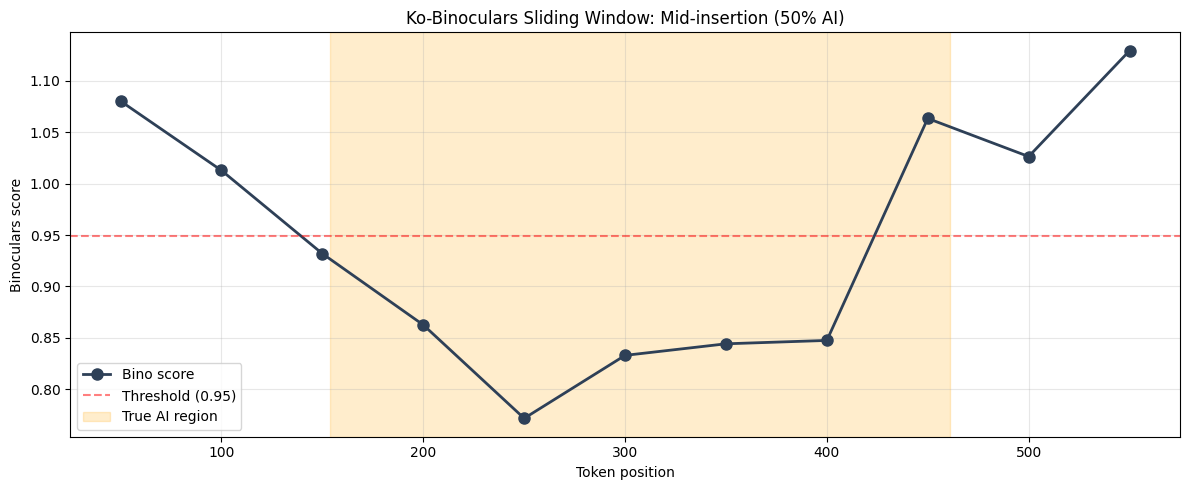

saved: segment_detection_viz.png


In [16]:
import matplotlib.pyplot as plt

# 대표 예시 하나: 50% Mid-insertion
h_text = test_pairs[0][0]
a_text = test_pairs[0][1]
hybrid, boundary = make_hybrid_middle(h_text, a_text, 0.5, tok_q1)
windows = sliding_window_scores(hybrid, m_q1, tok_q1, m_q2, tok_q2, device,
                                 window_size=100, stride=50)

positions = [(w['start']+w['end'])/2 for w in windows]
binos = [w['bino'] for w in windows]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(positions, binos, 'o-', color='#2E4057', linewidth=2, markersize=8, label='Bino score')
ax.axhline(y=thresh_bino, color='red', linestyle='--', alpha=0.5, label=f'Threshold ({thresh_bino:.2f})')
ax.axvspan(boundary[0], boundary[1], alpha=0.2, color='orange', label='True AI region')
ax.set_xlabel('Token position')
ax.set_ylabel('Binoculars score')
ax.set_title('Ko-Binoculars Sliding Window: Mid-insertion (50% AI)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('segment_detection_viz.png', dpi=150)
plt.show()
print("saved: segment_detection_viz.png")

In [ ]:
# 5. 핵심 실험: Human vs AI 문장별 분산 비교
h_texts = human_test['text'].tolist()[:30]
ai_texts = llm_groups['Solar']['text'].tolist()[:30]

print("Human 문장별 분산 계산 중...")
h_means, h_stds = [], []
for t in tqdm(h_texts):
    m, s = compute_sentence_variance(t, m_q1, tok_q1, m_q2, tok_q2, device)
    h_means.append(m)
    h_stds.append(s)

print("AI(Solar) 문장별 분산 계산 중...")
a_means, a_stds = [], []
for t in tqdm(ai_texts):
    m, s = compute_sentence_variance(t, m_q1, tok_q1, m_q2, tok_q2, device)
    a_means.append(m)
    a_stds.append(s)

print(f"\n{'':15} {'Mean Score':>12} {'Std (분산)':>12}")
print("-" * 42)
print(f"{'Human':<15} {np.mean(h_means):>12.4f} {np.mean(h_stds):>12.4f}")
print(f"{'AI (Solar)':<15} {np.mean(a_means):>12.4f} {np.mean(a_stds):>12.4f}")
print(f"\n사람 글의 분산이 {'높음' if np.mean(h_stds) > np.mean(a_stds) else '낮음'}")

Human 문장별 분산 계산 중...



  0%|          | 0/30 [00:00<?, ?it/s]WARNING:Kss:Oh! You have mecab in your environment. Kss will take this as a backend! :D


100%|██████████| 30/30 [00:35<00:00,  1.17s/it]


AI(Solar) 문장별 분산 계산 중...



100%|██████████| 30/30 [01:04<00:00,  2.15s/it]


                  Mean Score     Std (분산)
------------------------------------------
Human                 0.9473       0.1280
AI (Solar)            0.8393       0.1042

사람 글의 분산이 높음


In [ ]:
# 1. 전체 LLM 분산 확인 (30개씩, 빠르게)
print(f"{'Group':<15} {'Mean Score':>12} {'Std':>12}")
print("-" * 42)
print(f"{'Human':<15} {np.mean(h_means):>12.4f} {np.mean(h_stds):>12.4f}")

for llm_name, llm_df in llm_groups.items():
    texts = llm_df['text'].tolist()[:30]
    means, stds = [], []
    for t in tqdm(texts, desc=llm_name, leave=False):
        m, s = compute_sentence_variance(t, m_q1, tok_q1, m_q2, tok_q2, device)
        means.append(m)
        stds.append(s)
    print(f"{llm_name:<15} {np.mean(means):>12.4f} {np.mean(stds):>12.4f}")

Group             Mean Score          Std
------------------------------------------
Human                 0.9473       0.1280



Solar: 100%|██████████| 30/30 [01:04<00:00,  1.85s/it]
                                                      

Solar                 0.8393       0.1042



Qwen2: 100%|██████████| 30/30 [01:08<00:00,  2.41s/it]
                                                      

Qwen2                 0.9164       0.1038


Llama3.1              0.9127       0.1152


In [ ]:
# 2. 2D 분류 실험 (Human 94개 전부 + LLM 각 100개)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score

all_bino = []
all_std = []
all_labels = []

# Human 전부 (94개)
total_h = len(human_test)
for i, t in enumerate(human_test['text'].tolist()):
    bino = compute_binoculars_original(t, m_q1, tok_q1, m_q2, tok_q2, device)
    _, std = compute_sentence_variance(t, m_q1, tok_q1, m_q2, tok_q2, device)
    all_bino.append(bino)
    all_std.append(std)
    all_labels.append(0)
    print(f"\rHuman: {i+1}/{total_h}", end="")
print(" ✓")

# LLM 각 100개
for llm_name, llm_df in llm_groups.items():
    texts = llm_df['text'].tolist()[:100]
    total = len(texts)
    for i, t in enumerate(texts):
        bino = compute_binoculars_original(t, m_q1, tok_q1, m_q2, tok_q2, device)
        _, std = compute_sentence_variance(t, m_q1, tok_q1, m_q2, tok_q2, device)
        all_bino.append(bino)
        all_std.append(std)
        all_labels.append(1)
        print(f"\r{llm_name}: {i+1}/{total}", end="")
    print(" ✓")

all_bino = np.array(all_bino)
all_std = np.array(all_std)
all_labels = np.array(all_labels)
print(f"\n총 {len(all_labels)}개 (Human: {(all_labels==0).sum()}, AI: {(all_labels==1).sum()})")

# Bino only
auc_bino = roc_auc_score(all_labels, -all_bino) * 100

# Bino + Std
X = np.column_stack([all_bino, all_std])
scaler = StandardScaler()
X_s = scaler.fit_transform(X)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_s, all_labels)
prob = lr.predict_proba(X_s)[:, 1]
auc_2d = roc_auc_score(all_labels, prob) * 100
pred = lr.predict(X_s)
f1_2d = f1_score(all_labels, pred) * 100

print(f"\n{'Method':<25} {'ROC-AUC':>10}")
print("-" * 38)
print(f"{'Bino only':<25} {auc_bino:>10.2f}")
print(f"{'Bino + Variance (2D)':<25} {auc_2d:>10.2f}")
print(f"{'Δ':<25} {auc_2d - auc_bino:>+10.2f}")
print(f"\n2D F1: {f1_2d:.2f}")
print(f"Coefficients: bino={lr.coef_[0][0]:.4f}, std={lr.coef_[0][1]:.4f}")

Human: 94/94 ✓
Solar: 100/100 ✓
Qwen2: 100/100 ✓
Llama3.1: 100/100 ✓

총 394개 (Human: 94, AI: 300)

Method                       ROC-AUC
--------------------------------------
Bino only                      91.70
Bino + Variance (2D)           91.70
Δ                              -0.01

2D F1: 91.81
Coefficients: bino=-2.3275, std=-0.2652


In [ ]:
# 이미 계산된 all_bino, all_labels가 있으니까
# 문장별 스코어는 다시 계산해야 하지만, 일단 텍스트 레벨 통계량부터 확인

# 문장별 스코어를 저장해둔 게 없으니, 다른 접근:
# Binoculars 스코어의 토큰별 분포에서 통계량 추출

def compute_token_stats(text, m_obs, tok_obs, m_per, tok_per, device, max_length=256):
    """토큰별 cross-entropy에서 다양한 통계량 추출"""
    inp_o = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_p = tok_per(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_o2 = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        logits_o = m_obs(**inp_o2).logits
        logits_p = m_per(**inp_p).logits
    seq_len = min(logits_o.shape[1], logits_p.shape[1]) - 1
    if seq_len <= 0:
        return {'mean': 0, 'std': 0, 'max': 0, 'min': 0, 'skew': 0, 'range': 0}
    lo = logits_o[:, :seq_len, :]
    lp = logits_p[:, :seq_len, :]
    v = min(lo.shape[-1], lp.shape[-1])
    lo, lp = lo[..., :v], lp[..., :v]

    # 토큰별 cross-entropy
    ce = -(torch.softmax(lp[0], dim=-1) * torch.log_softmax(lo[0], dim=-1)).sum(-1)
    ce_np = ce.cpu().numpy()

    # 토큰별 NLL (observer)
    ids = inp_o['input_ids'][0, 1:seq_len+1]
    log_probs = torch.log_softmax(lo[0], dim=-1)
    nll = -log_probs[torch.arange(seq_len, device=device), ids]
    nll_np = nll.cpu().numpy()

    # 비율 (토큰별 binoculars)
    ratio = nll_np / (ce_np + 1e-10)

    from scipy import stats as sp_stats
    return {
        'bino': nll_np.mean() / (ce_np.mean() + 1e-10),  # 기존 binoculars
        'ce_std': ce_np.std(),           # CE 분산
        'nll_std': nll_np.std(),         # NLL 분산
        'ratio_std': ratio.std(),        # 토큰별 비율의 분산
        'ce_skew': sp_stats.skew(ce_np), # CE 왜도
        'nll_max': nll_np.max(),         # 최대 NLL
        'ce_range': ce_np.max() - ce_np.min(),  # CE 범위
        'ratio_max': ratio.max(),        # 최대 비율
    }

# Human 30 + Solar 30으로 빠르게 확인
h_stats = [compute_token_stats(t, m_q1, tok_q1, m_q2, tok_q2, device)
           for t in tqdm(human_test['text'].tolist()[:30], desc="Human")]
a_stats = [compute_token_stats(t, m_q1, tok_q1, m_q2, tok_q2, device)
           for t in tqdm(llm_groups['Solar']['text'].tolist()[:30], desc="Solar")]

h_df = pd.DataFrame(h_stats)
a_df = pd.DataFrame(a_stats)

print(f"\n{'Feature':<15} {'Human':>10} {'AI':>10} {'Diff':>10} {'Ratio':>10}")
print("-" * 58)
for col in h_df.columns:
    hm = h_df[col].mean()
    am = a_df[col].mean()
    diff = hm - am
    ratio = hm / (am + 1e-10)
    print(f"{col:<15} {hm:>10.4f} {am:>10.4f} {diff:>+10.4f} {ratio:>10.3f}")

Human:  90%|█████████ | 27/30 [00:02<00:00, 10.13it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
Solar:   7%|▋         | 2/30 [00:00<00:03,  7.74it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
Solar: 100%|██████████| 30/30 [00:03<00:00,  9.62it/s]


Feature              Human         AI       Diff      Ratio
----------------------------------------------------------
bino                1.0908     0.8291    +0.2617      1.315
ce_std              1.6562     1.4199    +0.2363      1.166
nll_std             2.4355     1.7021    +0.7334      1.431
ratio_std              inf        inf       +nan        nan
ce_skew             0.3921     0.8252    -0.4331      0.475
nll_max            11.9766     8.3984    +3.5781      1.426
ce_range            6.2578     6.2109    +0.0469      1.008
ratio_max          36.6875    29.6094    +7.0781      1.239



/tmp/ipykernel_7548/697340149.py:62: RuntimeWarning: invalid value encountered in scalar subtract
  diff = hm - am
/tmp/ipykernel_7548/697340149.py:63: RuntimeWarning: invalid value encountered in scalar divide
  ratio = hm / (am + 1e-10)


In [ ]:
from scipy import stats as sp_stats

def compute_features(text, m_obs, tok_obs, m_per, tok_per, device, max_length=256):
    inp_o = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_p = tok_per(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_o2 = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        loss_o = m_obs(**inp_o, labels=inp_o['input_ids']).loss.item()
        logits_o = m_obs(**inp_o2).logits
        logits_p = m_per(**inp_p).logits
    seq_len = min(logits_o.shape[1], logits_p.shape[1]) - 1
    if seq_len <= 0:
        return {'bino': 0, 'nll_std': 0, 'ce_skew': 0, 'nll_max': 0}
    lo = logits_o[:, :seq_len, :]
    lp = logits_p[:, :seq_len, :]
    v = min(lo.shape[-1], lp.shape[-1])
    lo, lp = lo[..., :v], lp[..., :v]

    ce = -(torch.softmax(lp[0], dim=-1) * torch.log_softmax(lo[0], dim=-1)).sum(-1)
    ce_np = ce.cpu().float().numpy()

    ids = inp_o['input_ids'][0, 1:seq_len+1]
    log_probs = torch.log_softmax(lo[0], dim=-1)
    nll = -log_probs[torch.arange(seq_len, device=device), ids]
    nll_np = nll.cpu().float().numpy()

    bino = loss_o / (ce_np.mean() + 1e-10)
    return {
        'bino': bino,
        'nll_std': nll_np.std(),
        'ce_skew': sp_stats.skew(nll_np),
        'nll_max': nll_np.max(),
    }

# Human 94개 + LLM 각 100개
all_feats = []
all_labels = []

total_h = len(human_test)
for i, t in enumerate(human_test['text'].tolist()):
    f = compute_features(t, m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(0)
    print(f"\rHuman: {i+1}/{total_h}", end="")
print(" ✓")

for llm_name, llm_df in llm_groups.items():
    texts = llm_df['text'].tolist()[:100]
    for i, t in enumerate(texts):
        f = compute_features(t, m_q1, tok_q1, m_q2, tok_q2, device)
        all_feats.append(f)
        all_labels.append(1)
        print(f"\r{llm_name}: {i+1}/{len(texts)}", end="")
    print(" ✓")

feat_df = pd.DataFrame(all_feats)
all_labels = np.array(all_labels)
print(f"\n총 {len(all_labels)}개")

# 조합별 AUC 비교
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score

combos = {
    'bino_only':            ['bino'],
    'bino+nll_std':         ['bino', 'nll_std'],
    'bino+ce_skew':         ['bino', 'ce_skew'],
    'bino+nll_std+ce_skew': ['bino', 'nll_std', 'ce_skew'],
    'bino+all3':            ['bino', 'nll_std', 'ce_skew', 'nll_max'],
}

print(f"\n{'Combo':<25} {'ROC-AUC':>10} {'Δ vs bino':>10}")
print("-" * 48)

base_auc = roc_auc_score(all_labels, -feat_df['bino'].values) * 100

for name, cols in combos.items():
    if len(cols) == 1:
        auc = roc_auc_score(all_labels, -feat_df[cols[0]].values) * 100
    else:
        X = feat_df[cols].values
        scaler = StandardScaler()
        X_s = scaler.fit_transform(X)
        lr = LogisticRegression(max_iter=1000, random_state=42)
        lr.fit(X_s, all_labels)
        prob = lr.predict_proba(X_s)[:, 1]
        auc = roc_auc_score(all_labels, prob) * 100
    print(f"{name:<25} {auc:>10.2f} {auc - base_auc:>+10.2f}")

Human: 94/94 ✓
Solar: 100/100 ✓
Qwen2: 100/100 ✓
Llama3.1: 100/100 ✓

총 394개

Combo                        ROC-AUC  Δ vs bino
------------------------------------------------
bino_only                      91.70      +0.00
bino+nll_std                   96.38      +4.68
bino+ce_skew                   91.73      +0.03
bino+nll_std+ce_skew           96.54      +4.84
bino+all3                      96.44      +4.74


In [ ]:
# 장르 매핑을 정확하게 다시
genres = []

# Human (94개) - human_test에서 직접 가져오기
for _, row in human_test.iterrows():
    genres.append(row['genre'])

# LLM 각 100개
for llm_name, llm_df in llm_groups.items():
    for _, row in llm_df.head(100).iterrows():
        genres.append(row['genre'])

feat_df['genre'] = genres
feat_df['label'] = all_labels

# 장르별 데이터 분포 확인
print("장르별 분포:")
print(feat_df.groupby(['genre', 'label']).size().unstack(fill_value=0))
print()

# Cross-Domain 평가
cols = ['bino', 'nll_std']
genre_list = feat_df['genre'].unique().tolist()

print(f"{'Train→Test':<25} {'Bino':>8} {'Bino+std':>10} {'Δ':>8}")
print("-" * 54)

bino_aucs = []
dual_aucs = []

for train_g in genre_list:
    train = feat_df[feat_df['genre'] == train_g]
    test  = feat_df[feat_df['genre'] != train_g]

    # 양쪽 다 두 클래스 있는지 확인
    if train['label'].nunique() < 2 or test['label'].nunique() < 2:
        print(f"{train_g+'→others':<25} 스킵 (클래스 부족)")
        continue

    # Bino only
    b_auc = roc_auc_score(test['label'], -test['bino'].values) * 100

    # Bino + nll_std
    X_tr = train[cols].values
    y_tr = train['label'].values
    X_te = test[cols].values
    y_te = test['label'].values

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr_s, y_tr)
    prob = lr.predict_proba(X_te_s)[:, 1]
    d_auc = roc_auc_score(y_te, prob) * 100

    bino_aucs.append(b_auc)
    dual_aucs.append(d_auc)
    print(f"{train_g+'→others':<25} {b_auc:>8.2f} {d_auc:>10.2f} {d_auc-b_auc:>+8.2f}")

print("-" * 54)
print(f"{'평균':<25} {np.mean(bino_aucs):>8.2f} {np.mean(dual_aucs):>10.2f} {np.mean(dual_aucs)-np.mean(bino_aucs):>+8.2f}")

장르별 분포:
label      0    1
genre            
abstract  13   12
essay     41  288
poetry    40    0

Train→Test                    Bino   Bino+std        Δ
------------------------------------------------------
essay→others                 56.45      64.62    +8.18
poetry→others             스킵 (클래스 부족)
abstract→others              93.17       9.06   -84.11
------------------------------------------------------
평균                           74.81      36.84   -37.97


In [ ]:
# 데이터 재구성: GPT-4o 제외, 전체 데이터 사용
# Human 20% 테스트 + Solar/Qwen2/Llama3.1 전체

# GPT-4o 제외한 LLM 데이터
llm_df = df_all[
    (df_all['label'] == 1) &
    (~df_all['written_by'].str.contains('gpt', case=False, na=False))
]

print("장르별 분포 (GPT-4o 제외):")
print(f"\nHuman 테스트셋: {len(human_test)}개")
print(human_test['genre'].value_counts())
print(f"\nLLM 데이터: {len(llm_df)}개")
print(llm_df.groupby(['genre', 'written_by']).size().unstack(fill_value=0))

장르별 분포 (GPT-4o 제외):

Human 테스트셋: 94개
genre
essay       41
poetry      40
abstract    13
Name: count, dtype: int64

LLM 데이터: 1154개
written_by  llama3.1:70b  qwen2:72b-instruct  solar-1-mini-chat
genre                                                          
abstract              61                  17                100
essay                 88                 181                140
poetry               189                 189                189


In [ ]:
# 피처 추출: 전체 데이터
from scipy import stats as sp_stats

all_feats = []
all_labels = []
all_genres = []

# Human 테스트셋 전체
total_h = len(human_test)
for i, (_, row) in enumerate(human_test.iterrows()):
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(0)
    all_genres.append(row['genre'])
    print(f"\rHuman: {i+1}/{total_h}", end="")
print(" ✓")

# LLM 전체 (GPT-4o 제외)
total_l = len(llm_df)
for i, (_, row) in enumerate(llm_df.iterrows()):
    f = compute_features(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(1)
    all_genres.append(row['genre'])
    print(f"\r LLM: {i+1}/{total_l}", end="")
print(" ✓")

feat_df = pd.DataFrame(all_feats)
feat_df['label'] = all_labels
feat_df['genre'] = all_genres
print(f"\n총 {len(feat_df)}개")
print(feat_df.groupby(['genre', 'label']).size().unstack(fill_value=0))

Human: 94/94 ✓
 LLM: 1154/1154 ✓

총 1248개
label      0    1
genre            
abstract  13  178
essay     41  409
poetry    40  567


In [ ]:
# 평가: 전체 + Cross-Domain
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

cols = ['bino', 'nll_std']

# 1. 전체 (in-domain, 참고용)
b_auc = roc_auc_score(feat_df['label'], -feat_df['bino'].values) * 100
X = feat_df[cols].values
scaler = StandardScaler()
X_s = scaler.fit_transform(X)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_s, feat_df['label'].values)
prob = lr.predict_proba(X_s)[:, 1]
d_auc = roc_auc_score(feat_df['label'], prob) * 100
print(f"{'[전체]':<25} Bino: {b_auc:.2f}  Bino+std: {d_auc:.2f}  Δ: {d_auc-b_auc:+.2f}")

# 2. Cross-Domain
print(f"\n{'Train→Test':<25} {'Bino':>8} {'Bino+std':>10} {'Δ':>8}")
print("-" * 54)

genre_list = ['essay', 'abstract', 'poetry']
bino_aucs = []
dual_aucs = []

for train_g in genre_list:
    train = feat_df[feat_df['genre'] == train_g]
    test  = feat_df[feat_df['genre'] != train_g]

    if train['label'].nunique() < 2 or test['label'].nunique() < 2:
        print(f"{train_g+'→others':<25} 스킵 (클래스 부족)")
        continue

    b_auc = roc_auc_score(test['label'], -test['bino'].values) * 100

    X_tr = train[cols].values
    y_tr = train['label'].values
    X_te = test[cols].values
    y_te = test['label'].values

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr_s, y_tr)
    prob = lr.predict_proba(X_te_s)[:, 1]
    d_auc = roc_auc_score(y_te, prob) * 100

    bino_aucs.append(b_auc)
    dual_aucs.append(d_auc)
    print(f"{train_g+'→others':<25} {b_auc:>8.2f} {d_auc:>10.2f} {d_auc-b_auc:>+8.2f}")

if bino_aucs:
    print("-" * 54)
    print(f"{'평균':<25} {np.mean(bino_aucs):>8.2f} {np.mean(dual_aucs):>10.2f} {np.mean(dual_aucs)-np.mean(bino_aucs):>+8.2f}")

[전체]                      Bino: 85.70  Bino+std: 88.05  Δ: +2.35

Train→Test                    Bino   Bino+std        Δ
------------------------------------------------------
essay→others                 80.65      84.67    +4.01
abstract→others              90.40      38.10   -52.30
poetry→others                83.88      84.34    +0.46
------------------------------------------------------
평균                           84.98      69.03   -15.94


In [ ]:
# abstract가 왜 다른지 확인
print(f"{'Genre':<12} {'N_human':>8} {'N_llm':>8} {'bino_h':>8} {'bino_ai':>8} {'std_h':>8} {'std_ai':>8}")
print("-" * 66)

for genre in ['essay', 'abstract', 'poetry']:
    g_data = feat_df[feat_df['genre'] == genre]
    h = g_data[g_data['label'] == 0]
    a = g_data[g_data['label'] == 1]
    print(f"{genre:<12} {len(h):>8} {len(a):>8} {h['bino'].mean():>8.3f} {a['bino'].mean():>8.3f} {h['nll_std'].mean():>8.3f} {a['nll_std'].mean():>8.3f}")

Genre         N_human    N_llm   bino_h  bino_ai    std_h   std_ai
------------------------------------------------------------------
essay              41      409    1.080    0.906    2.309    1.797
abstract           13      178    1.074    1.050    2.217    2.273
poetry             40      567    1.084    0.937    2.572    2.019


In [ ]:
# 학습 없는 조합 테스트
feat_df['bino_x_std'] = feat_df['bino'] * feat_df['nll_std']
feat_df['bino_plus_std'] = feat_df['bino'] + feat_df['nll_std']
feat_df['bino_minus_std'] = feat_df['bino'] - feat_df['nll_std']

combos = {
    'bino':          'bino',
    'bino * std':    'bino_x_std',
    'bino + std':    'bino_plus_std',
    'bino - std':    'bino_minus_std',
    'nll_std only':  'nll_std',
}

print(f"\n{'Method':<20} {'전체':>8} {'essay→':>8} {'abs→':>8} {'poet→':>8} {'Avg CD':>8}")
print("-" * 58)

for name, col in combos.items():
    # 전체
    total = roc_auc_score(feat_df['label'], -feat_df[col].values) * 100

    # Cross-domain
    cd_aucs = []
    for train_g in ['essay', 'abstract', 'poetry']:
        test = feat_df[feat_df['genre'] != train_g]
        if test['label'].nunique() < 2:
            cd_aucs.append(0)
            continue
        cd_aucs.append(roc_auc_score(test['label'], -test[col].values) * 100)

    print(f"{name:<20} {total:>8.2f} {cd_aucs[0]:>8.2f} {cd_aucs[1]:>8.2f} {cd_aucs[2]:>8.2f} {np.mean(cd_aucs):>8.2f}")


Method                     전체   essay→     abs→    poet→   Avg CD
----------------------------------------------------------
bino                    85.70    80.65    90.40    83.88    84.98
bino * std              88.13    84.47    93.64    84.37    87.49
bino + std              87.99    84.67    93.69    84.04    87.47
bino - std              16.11    18.82     9.84    18.78    15.82
nll_std only            87.25    84.22    93.20    83.36    86.93


In [ ]:
# 전체 OOD 평가: Bino vs Bino*std
# Human 테스트셋 94개 + Solar/Qwen2/Llama3.1 전체

def compute_features(text, m_obs, tok_obs, m_per, tok_per, device, max_length=256):
    inp_o = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_p = tok_per(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_o2 = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        loss_o = m_obs(**inp_o, labels=inp_o['input_ids']).loss.item()
        logits_o = m_obs(**inp_o2).logits
        logits_p = m_per(**inp_p).logits
    seq_len = min(logits_o.shape[1], logits_p.shape[1]) - 1
    if seq_len <= 0:
        return 0.0, 0.0
    lo = logits_o[:, :seq_len, :]
    lp = logits_p[:, :seq_len, :]
    v = min(lo.shape[-1], lp.shape[-1])
    lo, lp = lo[..., :v], lp[..., :v]

    ce = -(torch.softmax(lp[0], dim=-1) * torch.log_softmax(lo[0], dim=-1)).sum(-1)
    bino = loss_o / (ce.mean().item() + 1e-10)

    ids = inp_o['input_ids'][0, 1:seq_len+1]
    log_probs = torch.log_softmax(lo[0], dim=-1)
    nll = -log_probs[torch.arange(seq_len, device=device), ids]
    nll_std = nll.cpu().float().numpy().std()

    return bino, nll_std

# Human 스코어
print("Human 스코어 계산 중...")
h_bino, h_std = [], []
total_h = len(human_test)
for i, t in enumerate(human_test['text'].tolist()):
    b, s = compute_features(t, m_q1, tok_q1, m_q2, tok_q2, device)
    h_bino.append(b)
    h_std.append(s)
    print(f"\rHuman: {i+1}/{total_h}", end="")
print(" ✓")
h_bino = np.array(h_bino)
h_std = np.array(h_std)
h_combined = h_bino * h_std

# LLM별 스코어
llm_results = {}
for llm_name, llm_df in llm_groups.items():
    texts = llm_df['text'].tolist()
    l_bino, l_std = [], []
    for i, t in enumerate(texts):
        b, s = compute_features(t, m_q1, tok_q1, m_q2, tok_q2, device)
        l_bino.append(b)
        l_std.append(s)
        print(f"\r{llm_name}: {i+1}/{len(texts)}", end="")
    print(" ✓")
    llm_results[llm_name] = {
        'bino': np.array(l_bino),
        'std': np.array(l_std),
        'combined': np.array(l_bino) * np.array(l_std),
    }

# 결과 출력
print(f"\n{'='*70}")
print(f"Qwen2.5-3B + Qwen2.5-3B-Instruct 결과")
print(f"{'='*70}")
print(f"\n{'LLM':<12} {'Bino AUC':>10} {'B*σ AUC':>10} {'Δ AUC':>8} {'Bino R@5%':>10} {'B*σ R@5%':>10} {'Δ R@5%':>8}")
print("-" * 72)

def find_threshold(scores, labels, target_fpr=0.05):
    thresholds = np.linspace(scores.min(), scores.max(), 1000)
    best_thresh, best_recall = None, 0
    for t in thresholds:
        preds = (scores >= t).astype(int)
        fp = ((preds==1) & (labels==0)).sum()
        tn = ((preds==0) & (labels==0)).sum()
        tp = ((preds==1) & (labels==1)).sum()
        fn = ((preds==0) & (labels==1)).sum()
        fpr = fp / (fp + tn + 1e-10)
        recall = tp / (tp + fn + 1e-10)
        if fpr <= target_fpr and recall > best_recall:
            best_recall = recall
            best_thresh = t
    return best_thresh, best_recall

b_aucs, c_aucs = [], []
b_r5s, c_r5s = [], []

for llm_name in llm_groups.keys():
    lr = llm_results[llm_name]

    # Bino only
    sc_b = np.concatenate([h_bino, lr['bino']])
    lb = np.array([0]*len(h_bino) + [1]*len(lr['bino']))
    auc_b = roc_auc_score(lb, -sc_b) * 100
    _, r5_b = find_threshold(-sc_b, lb, 0.05)

    # Bino * std
    sc_c = np.concatenate([h_combined, lr['combined']])
    auc_c = roc_auc_score(lb, -sc_c) * 100
    _, r5_c = find_threshold(-sc_c, lb, 0.05)

    b_aucs.append(auc_b); c_aucs.append(auc_c)
    b_r5s.append(r5_b*100); c_r5s.append(r5_c*100)

    print(f"{llm_name:<12} {auc_b:>10.2f} {auc_c:>10.2f} {auc_c-auc_b:>+8.2f} {r5_b*100:>10.2f} {r5_c*100:>10.2f} {r5_c*100-r5_b*100:>+8.2f}")

print("-" * 72)
print(f"{'평균':<12} {np.mean(b_aucs):>10.2f} {np.mean(c_aucs):>10.2f} {np.mean(c_aucs)-np.mean(b_aucs):>+8.2f} {np.mean(b_r5s):>10.2f} {np.mean(c_r5s):>10.2f} {np.mean(c_r5s)-np.mean(b_r5s):>+8.2f}")

Human 스코어 계산 중...
Human: 94/94 ✓
Solar: 429/429 ✓
Qwen2: 387/387 ✓
Llama3.1: 338/338 ✓

Qwen2.5-3B + Qwen2.5-3B-Instruct 결과

LLM            Bino AUC    B*σ AUC    Δ AUC  Bino R@5%   B*σ R@5%   Δ R@5%
------------------------------------------------------------------------
Solar             89.46      88.99    -0.47      74.13      69.46    -4.66
Qwen2             82.78      88.36    +5.58      39.79      44.96    +5.17
Llama3.1          84.29      86.79    +2.50      54.73      52.66    -2.07
------------------------------------------------------------------------
평균                85.51      88.05    +2.54      56.22      55.70    -0.52


In [ ]:
from mecab import MeCab
mecab_obj = MeCab()

def normalize_korean(text):
    """형태소 단위로 띄어쓰기 삽입"""
    morphs = mecab_obj.morphs(text)
    return ' '.join(morphs)

# 테스트
sample = "인공지능이 생성한 텍스트를 탐지하는 것은 어렵다."
print(f"원문:   {sample}")
print(f"정규화: {normalize_korean(sample)}")

# 빠른 비교: 원문 vs 정규화 Binoculars
h_texts = human_test['text'].tolist()[:30]
ai_texts = llm_groups['Solar']['text'].tolist()[:30]

print(f"\n{'Method':<20} {'H_mean':>8} {'AI_mean':>8} {'Gap':>8}")
print("-" * 48)

# 원문
h1 = [compute_binoculars_original(t, m_q1, tok_q1, m_q2, tok_q2, device) for t in h_texts]
a1 = [compute_binoculars_original(t, m_q1, tok_q1, m_q2, tok_q2, device) for t in ai_texts]
print(f"{'Original':20} {np.mean(h1):>8.4f} {np.mean(a1):>8.4f} {np.mean(h1)-np.mean(a1):>+8.4f}")

# 정규화
h2 = [compute_binoculars_original(normalize_korean(t), m_q1, tok_q1, m_q2, tok_q2, device) for t in h_texts]
a2 = [compute_binoculars_original(normalize_korean(t), m_q1, tok_q1, m_q2, tok_q2, device) for t in ai_texts]
print(f"{'Normalized':20} {np.mean(h2):>8.4f} {np.mean(a2):>8.4f} {np.mean(h2)-np.mean(a2):>+8.4f}")

원문:   인공지능이 생성한 텍스트를 탐지하는 것은 어렵다.
정규화: 인공지능 이 생성 한 텍스트 를 탐지 하 는 것 은 어렵 다 .

Method                 H_mean  AI_mean      Gap
------------------------------------------------
Original               1.0904   0.8290  +0.2614
Normalized             1.1635   0.9668  +0.1967


In [ ]:
FUNCTIONAL_POS = {'JKS','JKC','JKG','JKO','JKB','JKV','JKQ','JX','JC',
                  'EP','EF','EC','ETN','ETM','XPN','XSN','XSV','XSA',
                  'SF','SP','SS','SE','SO','SW'}

def remove_functional(text):
    """기능 형태소 제거, 실질 형태소만 남기기"""
    result = []
    for morph, pos in mecab_obj.pos(text):
        if pos not in FUNCTIONAL_POS:
            result.append(morph)
    return ' '.join(result)

sample = "인공지능이 생성한 텍스트를 탐지하는 것은 어렵다."
print(f"원문:     {sample}")
print(f"실질만:   {remove_functional(sample)}")

# 비교
h3 = [compute_binoculars_original(remove_functional(t), m_q1, tok_q1, m_q2, tok_q2, device) for t in h_texts]
a3 = [compute_binoculars_original(remove_functional(t), m_q1, tok_q1, m_q2, tok_q2, device) for t in ai_texts]

print(f"\n{'Method':<20} {'H_mean':>8} {'AI_mean':>8} {'Gap':>8}")
print("-" * 48)
print(f"{'Original':20} {np.mean(h1):>8.4f} {np.mean(a1):>8.4f} {np.mean(h1)-np.mean(a1):>+8.4f}")
print(f"{'Normalized':20} {np.mean(h2):>8.4f} {np.mean(a2):>8.4f} {np.mean(h2)-np.mean(a2):>+8.4f}")
print(f"{'Content only':20} {np.mean(h3):>8.4f} {np.mean(a3):>8.4f} {np.mean(h3)-np.mean(a3):>+8.4f}")

원문:     인공지능이 생성한 텍스트를 탐지하는 것은 어렵다.
실질만:   인공지능 생성 한 텍스트 탐지 것 어렵

Method                 H_mean  AI_mean      Gap
------------------------------------------------
Original               1.0904   0.8290  +0.2614
Normalized             1.1635   0.9668  +0.1967
Content only           1.1853   1.0578  +0.1275


In [ ]:
def compute_multi_metrics(text, m_obs, tok_obs, m_per, tok_per, device, max_length=256):
    """Binoculars + Log-Rank + Entropy + NLL std 한번에 계산"""
    inp_o = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_p = tok_per(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    inp_o2 = tok_obs(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
    with torch.no_grad():
        loss_o = m_obs(**inp_o, labels=inp_o['input_ids']).loss.item()
        logits_o = m_obs(**inp_o2).logits
        logits_p = m_per(**inp_p).logits

    seq_len = min(logits_o.shape[1], logits_p.shape[1]) - 1
    if seq_len <= 0:
        return {'bino': 0, 'log_rank': 0, 'entropy': 0, 'nll_std': 0, 'log_likelihood': 0}

    lo = logits_o[:, :seq_len, :]
    lp = logits_p[:, :seq_len, :]
    v = min(lo.shape[-1], lp.shape[-1])
    lo, lp = lo[..., :v], lp[..., :v]

    # Binoculars
    ce = -(torch.softmax(lp[0], dim=-1) * torch.log_softmax(lo[0], dim=-1)).sum(-1)
    bino = loss_o / (ce.mean().item() + 1e-10)

    # 토큰별 NLL, Rank, Entropy (Observer 기준)
    ids = inp_o['input_ids'][0, 1:seq_len+1]
    log_probs = torch.log_softmax(lo[0], dim=-1)
    nll = -log_probs[torch.arange(seq_len, device=device), ids]

    # Log-Rank: 각 토큰의 순위
    ranks = []
    for t in range(seq_len):
        sorted_idx = lo[0, t].argsort(descending=True)
        rank = (sorted_idx == ids[t]).nonzero(as_tuple=True)[0].item()
        ranks.append(np.log(rank + 1))
    avg_log_rank = np.mean(ranks)

    # Entropy: 예측 분포의 엔트로피
    probs = torch.softmax(lo[0], dim=-1)
    ent = -(probs * torch.log(probs + 1e-10)).sum(-1)
    avg_entropy = ent.mean().item()

    # NLL std
    nll_std = nll.cpu().float().numpy().std()

    # Log-Likelihood
    log_likelihood = -loss_o

    return {
        'bino': bino,
        'log_rank': avg_log_rank,
        'entropy': avg_entropy,
        'nll_std': nll_std,
        'log_likelihood': log_likelihood,
    }

print("함수 정의 완료")

함수 정의 완료


In [ ]:
# 전체 데이터 피처 추출 (Human 94 + LLM 전체, GPT-4o 제외)
llm_df = df_all[
    (df_all['label'] == 1) &
    (~df_all['written_by'].str.contains('gpt', case=False, na=False))
]

all_feats = []
all_labels = []

total_h = len(human_test)
for i, (_, row) in enumerate(human_test.iterrows()):
    f = compute_multi_metrics(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(0)
    print(f"\rHuman: {i+1}/{total_h}", end="")
print(" ✓")

total_l = len(llm_df)
for i, (_, row) in enumerate(llm_df.iterrows()):
    f = compute_multi_metrics(row['text'], m_q1, tok_q1, m_q2, tok_q2, device)
    all_feats.append(f)
    all_labels.append(1)
    print(f"\rLLM: {i+1}/{total_l}", end="")
print(" ✓")

feat_df = pd.DataFrame(all_feats)
feat_df['label'] = all_labels
print(f"\n총 {len(feat_df)}개")
print(f"\nHuman vs AI 평균:")
print(feat_df.groupby('label')[['bino','log_rank','entropy','nll_std','log_likelihood']].mean())

=== 단독 메트릭 AUC ===
Metric                    AUC
------------------------------
bino                    85.70
log_rank                77.98
nll_std                 87.25
log_likelihood          76.67

=== 학습 없는 결합 (정규화 후 평균) ===
Combo                               AUC  Δ vs bino
--------------------------------------------------
bino only                         85.70      +0.00
log_rank only                     77.98      -7.73
nll_std only                      87.25      +1.54
log_likelihood only               76.67      -9.04
bino + log_rank                   85.02      -0.69
bino + nll_std                    87.95      +2.25
bino + log_likelihood             84.64      -1.06
bino + log_rank + nll_std         86.57      +0.87
log_rank + nll_std                83.64      -2.06
all 4                             84.65      -1.05


In [ ]:
# 단독 메트릭 AUC (entropy 제외)
print("=== 단독 메트릭 AUC ===")
print(f"{'Metric':<20} {'AUC':>8}")
print("-" * 30)

labels = feat_df['label'].values
for col, flip in [('bino', -1), ('log_rank', -1),
                   ('nll_std', -1), ('log_likelihood', 1)]:
    auc = roc_auc_score(labels, flip * feat_df[col].values) * 100
    print(f"{col:<20} {auc:>8.2f}")

# 정규화
from sklearn.preprocessing import MinMaxScaler

scores = {}
for col, flip in [('bino', -1), ('log_rank', -1),
                   ('nll_std', -1), ('log_likelihood', 1)]:
    raw = flip * feat_df[col].values.reshape(-1, 1)
    scaled = MinMaxScaler().fit_transform(raw).flatten()
    scores[col] = scaled

# 결합 실험
combos = {
    'bino only':                    ['bino'],
    'log_rank only':                ['log_rank'],
    'nll_std only':                 ['nll_std'],
    'log_likelihood only':          ['log_likelihood'],
    'bino + log_rank':              ['bino', 'log_rank'],
    'bino + nll_std':               ['bino', 'nll_std'],
    'bino + log_likelihood':        ['bino', 'log_likelihood'],
    'bino + log_rank + nll_std':    ['bino', 'log_rank', 'nll_std'],
    'log_rank + nll_std':           ['log_rank', 'nll_std'],
    'all 4':                        ['bino', 'log_rank', 'nll_std', 'log_likelihood'],
}

print(f"\n=== 학습 없는 결합 (정규화 후 평균) ===")
print(f"{'Combo':<30} {'AUC':>8} {'Δ vs bino':>10}")
print("-" * 50)

base_auc = roc_auc_score(labels, scores['bino']) * 100

for name, cols in combos.items():
    combined = np.mean([scores[c] for c in cols], axis=0)
    auc = roc_auc_score(labels, combined) * 100
    print(f"{name:<30} {auc:>8.2f} {auc - base_auc:>+10.2f}")

=== 단독 메트릭 AUC ===
Metric                    AUC
------------------------------
bino                    85.70
log_rank                77.98
nll_std                 87.25
log_likelihood          76.67

=== 학습 없는 결합 (정규화 후 평균) ===
Combo                               AUC  Δ vs bino
--------------------------------------------------
bino only                         85.70      +0.00
log_rank only                     77.98      -7.73
nll_std only                      87.25      +1.54
log_likelihood only               76.67      -9.04
bino + log_rank                   85.02      -0.69
bino + nll_std                    87.95      +2.25
bino + log_likelihood             84.64      -1.06
bino + log_rank + nll_std         86.57      +0.87
log_rank + nll_std                83.64      -2.06
all 4                             84.65      -1.05


In [ ]:
# bino와 nll_std 가중 결합 탐색
print(f"{'Weight (bino:std)':<25} {'AUC':>8} {'Δ vs bino':>10}")
print("-" * 46)

base_auc = roc_auc_score(labels, scores['bino']) * 100

for w_bino in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    w_std = 1.0 - w_bino
    combined = w_bino * scores['bino'] + w_std * scores['nll_std']
    auc = roc_auc_score(labels, combined) * 100
    marker = " ←" if auc > 87.95 else ""
    print(f"{f'{w_bino:.1f} : {w_std:.1f}':<25} {auc:>8.2f} {auc - base_auc:>+10.2f}{marker}")

# 곱하기도 시도 (정규화 전 원본으로)
bino_raw = -feat_df['bino'].values
std_raw = -feat_df['nll_std'].values

auc_mult = roc_auc_score(labels, bino_raw * std_raw) * 100
auc_bino_raw = roc_auc_score(labels, bino_raw) * 100

print(f"\n{'원본 곱하기 (bino*std)':<25} {auc_mult:>8.2f} {auc_mult - auc_bino_raw:>+10.2f}")

# 제곱근 조합도
auc_sqrt = roc_auc_score(labels, np.sign(bino_raw) * np.sqrt(np.abs(bino_raw)) * std_raw) * 100
print(f"{'sqrt(bino)*std':<25} {auc_sqrt:>8.2f} {auc_sqrt - auc_bino_raw:>+10.2f}")

Weight (bino:std)              AUC  Δ vs bino
----------------------------------------------
0.1 : 0.9                    87.70      +2.00
0.2 : 0.8                    87.95      +2.24
0.3 : 0.7                    88.08      +2.38 ←
0.4 : 0.6                    88.11      +2.40 ←
0.5 : 0.5                    87.95      +2.25 ←
0.6 : 0.4                    87.63      +1.92
0.7 : 0.3                    87.25      +1.55
0.8 : 0.2                    86.79      +1.09
0.9 : 0.1                    86.28      +0.58

원본 곱하기 (bino*std)            11.87     -73.84
sqrt(bino)*std               11.96     -73.74


In [ ]:
# LLM별 + 장르별 검증
# 이미 feat_df에 전체 데이터가 있으니까 장르 매핑 추가

genres = []
for _, row in human_test.iterrows():
    genres.append(row['genre'])
for _, row in llm_df.iterrows():
    genres.append(row['genre'])
feat_df['genre'] = genres

# written_by 매핑
writers = []
for _, row in human_test.iterrows():
    writers.append('Human')
for _, row in llm_df.iterrows():
    writers.append(row['written_by'])
feat_df['writer'] = writers

# 정규화 스코어 + 결합 스코어 추가
feat_df['score_bino'] = MinMaxScaler().fit_transform(-feat_df[['bino']]).flatten()
feat_df['score_std'] = MinMaxScaler().fit_transform(-feat_df[['nll_std']]).flatten()
feat_df['score_combined'] = 0.4 * feat_df['score_bino'] + 0.6 * feat_df['score_std']

# 1. LLM별 비교
print("=== LLM별 AUC 비교 ===")
print(f"{'LLM':<15} {'Bino':>8} {'NLL_std':>8} {'Combined':>10} {'Δ':>8}")
print("-" * 52)

human_data = feat_df[feat_df['label'] == 0]
llm_names = ['solar', 'qwen', 'llama']
display_names = ['Solar', 'Qwen2', 'Llama3.1']

b_aucs, c_aucs = [], []
for llm_match, llm_disp in zip(llm_names, display_names):
    ai_data = feat_df[(feat_df['label'] == 1) &
                       (feat_df['writer'].str.contains(llm_match, case=False))]
    subset = pd.concat([human_data, ai_data])
    lb = subset['label'].values

    auc_b = roc_auc_score(lb, subset['score_bino'].values) * 100
    auc_s = roc_auc_score(lb, subset['score_std'].values) * 100
    auc_c = roc_auc_score(lb, subset['score_combined'].values) * 100
    b_aucs.append(auc_b); c_aucs.append(auc_c)
    print(f"{llm_disp:<15} {auc_b:>8.2f} {auc_s:>8.2f} {auc_c:>10.2f} {auc_c-auc_b:>+8.2f}")

print("-" * 52)
print(f"{'평균':<15} {np.mean(b_aucs):>8.2f} {'':>8} {np.mean(c_aucs):>10.2f} {np.mean(c_aucs)-np.mean(b_aucs):>+8.2f}")

# 2. 장르별 비교
print(f"\n=== 장르별 AUC 비교 ===")
print(f"{'Genre':<15} {'Bino':>8} {'NLL_std':>8} {'Combined':>10} {'Δ':>8}")
print("-" * 52)

for genre in ['essay', 'abstract', 'poetry']:
    subset = feat_df[feat_df['genre'] == genre]
    if subset['label'].nunique() < 2:
        print(f"{genre:<15} 스킵")
        continue
    lb = subset['label'].values
    auc_b = roc_auc_score(lb, subset['score_bino'].values) * 100
    auc_s = roc_auc_score(lb, subset['score_std'].values) * 100
    auc_c = roc_auc_score(lb, subset['score_combined'].values) * 100
    print(f"{genre:<15} {auc_b:>8.2f} {auc_s:>8.2f} {auc_c:>10.2f} {auc_c-auc_b:>+8.2f}")

=== LLM별 AUC 비교 ===
LLM                 Bino  NLL_std   Combined        Δ
----------------------------------------------------
Solar              89.46    86.59      89.04    -0.42
Qwen2              82.78    89.36      88.20    +5.42
Llama3.1           84.29    85.67      86.83    +2.54
----------------------------------------------------
평균                 85.51               88.02    +2.51

=== 장르별 AUC 비교 ===
Genre               Bino  NLL_std   Combined        Δ
----------------------------------------------------
essay              94.98    98.36      97.82    +2.84
abstract           56.57    43.69      49.39    -7.17
poetry             86.84    93.51      92.31    +5.46
